## Genomics

# **Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.**

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

The training mean squared error was basically 0.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

Using 5-fold cross validation, the mean squared error increased to 0.0409. This is much higher than the training error. This basically means that the model is overfitting. The model has low bias since it fits the training data almost perfectly, but high variance since it relies on so many predictors. It does not generalize as well to new data.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

The model selected 68 genes as important predictors and shrunk the remaining 7062 genes to zero. THis shows that only a small certain amount of genes are useful for prediction. Some of the strongest predictors included genes like
Using cross-validated LASSO, the model selected 67 genes as important predictors and shrunk the remaining 7062 genes to zero. Some of the strongest predictors included genes like M19507_at, M27891_at, and M31994_at.


5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

When you look at how cross-validated MSE changes as alpha changes, you see that a very large values of alpha cause the model to underfit because too many coefficients are zero. Small values of slpha can cause the model to overfit due to the fact that the penalty becomes week and the model begins to change and behave like a regular linear regression. The optimal value of alpha that minimizes expected prediction error was approximately 0.00259, this balances the model simplicity and predictive accuracy.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression fits the training data well because of the number of predictors is quite large compared to onservations. This gives the model the ability to memorize the data. It does laos lead to poor generalization and overfitting. LASSO improves predictinos because it adds a penalty by reducing the complexity of the model.

7. Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods work well in precision health cause the datasets have lots of different variables but few patients. LASSO helps prevent overfitting, identify a smaller set of important biological markers, improve prediction accuracy. The model is more interpretable and useful for decision making because of this.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

The risks of applying methods like the Lasso to precision health questions could be that LASSO may eliminate variables that are biologically important if they are highly correlated with other predictors. Another risk that comes to mind is that results from small datasets may not generalize well to broader populations.
Also, if you rely too heavily on statistical models without clinical validation could lead to incorrect treatment decisions or unintended bias in healthcare outcomes.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("golub.csv")

meta_cols = ['Samples','BM.PB','Gender','Source','tissue.mf','cancer']

X = df.drop(columns=meta_cols)

y = df['cancer'].map({
    'allB':0,
    'allT':0,
    'aml':1
})

print("Dataset shape:", X.shape)
print("Class counts:")
print(y.value_counts())

Dataset shape: (72, 7129)
Class counts:
cancer
0    47
1    25
Name: count, dtype: int64


In [11]:
lr = LinearRegression()
lr.fit(X,y)

y_pred = lr.predict(X)

mse_train = mean_squared_error(y,y_pred)
print("Training MSE:", mse_train)

Training MSE: 1.2522824482837894e-30


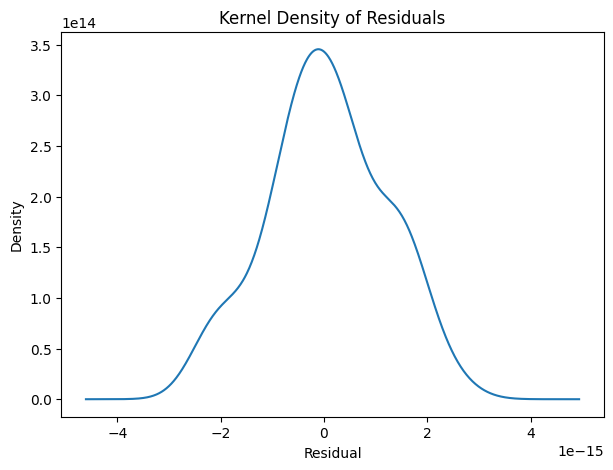

In [12]:
residuals = y - y_pred

plt.figure(figsize=(7,5))
pd.Series(residuals).plot(kind="kde")
plt.title("Kernel Density of Residuals")
plt.xlabel("Residual")
plt.show()

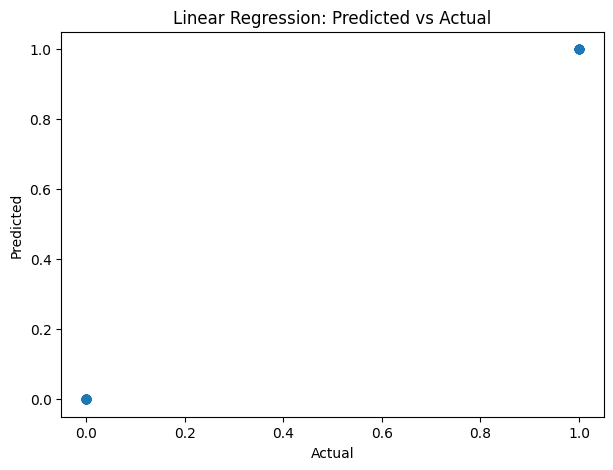

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(y, y_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_pred = cross_val_predict(lr, X, y, cv=cv)

mse_cv = mean_squared_error(y, cv_pred)

print("Cross-validated MSE:", mse_cv)

Cross-validated MSE: 0.040931206353316346


In [15]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=cv, random_state=42, max_iter=20000))
])

pipe.fit(X,y)

lasso = pipe.named_steps["lasso"]

best_alpha = lasso.alpha_

lasso_pred = pipe.predict(X)

lasso_mse_train = mean_squared_error(y, lasso_pred)

print("Best alpha:", best_alpha)
print("LASSO Training MSE:", lasso_mse_train)

Best alpha: 0.0029010245894434514
LASSO Training MSE: 0.0001341815057888466


In [16]:
coef = pd.Series(lasso.coef_, index=X.columns)

selected_genes = coef[coef != 0]

print("Number of selected genes:", selected_genes.shape[0])
print("Number of discarded genes:", (coef == 0).sum())

selected_genes.sort_values(key=np.abs, ascending=False).head(20)

Number of selected genes: 68
Number of discarded genes: 7061


,0
M19507_at,0.116934
M27891_at,0.062591
M31994_at,0.058099
M22960_at,0.043752
M26708_s_at,-0.042226
M13690_s_at,0.038349
Y10207_at,-0.037720
M23197_at,0.032835
M63138_at,0.030905
M96326_rna1_at,0.029743


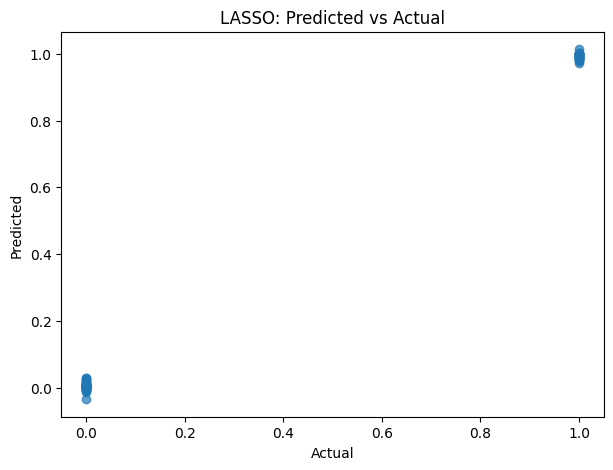

In [17]:
plt.figure(figsize=(7,5))
plt.scatter(y, lasso_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO: Predicted vs Actual")
plt.show()

In [18]:
lasso_cv_pred = cross_val_predict(
    Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(cv=5, random_state=42, max_iter=20000))
    ]),
    X, y, cv=cv
)

lasso_cv_mse = mean_squared_error(y, lasso_cv_pred)

print("LASSO CV MSE:", lasso_cv_mse)

LASSO CV MSE: 0.05601766233402426


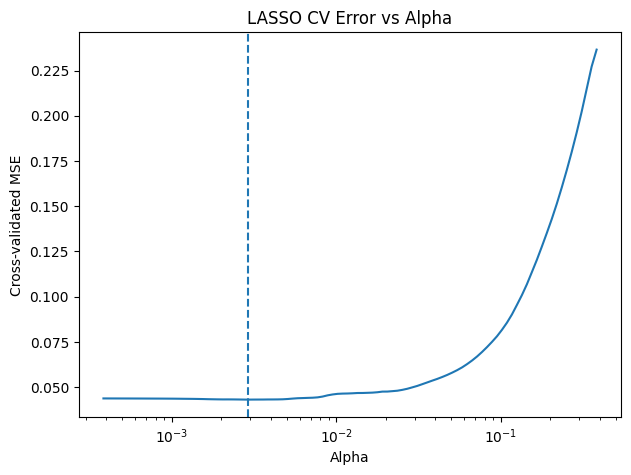

In [19]:
alphas = lasso.alphas_
mse_path = lasso.mse_path_.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(alphas, mse_path)
plt.axvline(best_alpha, linestyle="--")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("LASSO CV Error vs Alpha")
plt.show()